# **CHRONIC LIVER Dataset - Exploratory Data Analysis**
Importing Required Libraries:
pandas → for data manipulation
numpy → for numerical operations
matplotlib & seaborn → for visualization

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression

In [2]:
import pandas as pd
import numpy as np

data = pd.read_csv("Indian Liver Patient Dataset (ILPD).csv", header=None)
data.columns = [
    "Age",
    "Gender",
    "Total_Bilirubin",
    "Direct_Bilirubin",
    "Alkaline_Phosphotase",
    "Alamine_Aminotransferase",
    "Aspartate_Aminotransferase",
    "Total_Protiens",
    "Albumin",
    "Albumin_and_Globulin_Ratio",
    "Output",
]

data.head()

,Age,Gender,Total_Bilirubin,Direct_Bilirubin,Alkaline_Phosphotase,Alamine_Aminotransferase,Aspartate_Aminotransferase,Total_Protiens,Albumin,Albumin_and_Globulin_Ratio,Output
0,65,Female,0.7,0.1,187,16,18,6.8,3.3,0.90,1
1,62,Male,10.9,5.5,699,64,100,7.5,3.2,0.74,1
2,62,Male,7.3,4.1,490,60,68,7.0,3.3,0.89,1
3,58,Male,1.0,0.4,182,14,20,6.8,3.4,1.00,1
4,72,Male,3.9,2.0,195,27,59,7.3,2.4,0.40,1


In [3]:
print("Number of rows and columns:")
print(data.shape)

print("\nColumn names:")
print(data.columns)

print("\nDataset info:")
data.info()

Number of rows and columns:
(583, 11)

Column names:
Index(['Age', 'Gender', 'Total_Bilirubin', 'Direct_Bilirubin',
       'Alkaline_Phosphotase', 'Alamine_Aminotransferase',
       'Aspartate_Aminotransferase', 'Total_Protiens', 'Albumin',
       'Albumin_and_Globulin_Ratio', 'Output'],
      dtype='str')

Dataset info:
<class 'pandas.DataFrame'>
RangeIndex: 583 entries, 0 to 582
Data columns (total 11 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Age                         583 non-null    int64  
 1   Gender                      583 non-null    str    
 2   Total_Bilirubin             583 non-null    float64
 3   Direct_Bilirubin            583 non-null    float64
 4   Alkaline_Phosphotase        583 non-null    int64  
 5   Alamine_Aminotransferase    583 non-null    int64  
 6   Aspartate_Aminotransferase  583 non-null    int64  
 7   Total_Protiens              583 non-null    float64
 8   Albumin 

### Target Variable

The target variable in this dataset is **Output**.

Values:
1 → Liver Disease Patient  
2 → Non Liver Disease Patient

In [4]:
data.isnull().sum()

Age                           0
Gender                        0
Total_Bilirubin               0
Direct_Bilirubin              0
Alkaline_Phosphotase          0
Alamine_Aminotransferase      0
Aspartate_Aminotransferase    0
Total_Protiens                0
Albumin                       0
Albumin_and_Globulin_Ratio    4
Output                        0
dtype: int64

In [5]:
data = data.fillna(data.mean(numeric_only=True))

data.isnull().sum()

Age                           0
Gender                        0
Total_Bilirubin               0
Direct_Bilirubin              0
Alkaline_Phosphotase          0
Alamine_Aminotransferase      0
Aspartate_Aminotransferase    0
Total_Protiens                0
Albumin                       0
Albumin_and_Globulin_Ratio    0
Output                        0
dtype: int64

In [6]:
data.dtypes

Age                             int64
Gender                            str
Total_Bilirubin               float64
Direct_Bilirubin              float64
Alkaline_Phosphotase            int64
Alamine_Aminotransferase        int64
Aspartate_Aminotransferase      int64
Total_Protiens                float64
Albumin                       float64
Albumin_and_Globulin_Ratio    float64
Output                          int64
dtype: object

**Converting String Columns to Numeric**
Values:
1 → Male Patient  
0 → Female Patient

In [7]:
label = LabelEncoder()
data["Gender"] = label.fit_transform(data["Gender"])

data.head()

,Age,Gender,Total_Bilirubin,Direct_Bilirubin,Alkaline_Phosphotase,Alamine_Aminotransferase,Aspartate_Aminotransferase,Total_Protiens,Albumin,Albumin_and_Globulin_Ratio,Output
0,65,0,0.7,0.1,187,16,18,6.8,3.3,0.90,1
1,62,1,10.9,5.5,699,64,100,7.5,3.2,0.74,1
2,62,1,7.3,4.1,490,60,68,7.0,3.3,0.89,1
3,58,1,1.0,0.4,182,14,20,6.8,3.4,1.00,1
4,72,1,3.9,2.0,195,27,59,7.3,2.4,0.40,1


In [8]:
numerical_features = data.select_dtypes(include=['int64','float64']).columns
categorical_features = data.select_dtypes(include=['object']).columns

print("Numerical features:")
print(numerical_features)

print("\nCategorical features:")
print(categorical_features)

Numerical features:
Index(['Age', 'Gender', 'Total_Bilirubin', 'Direct_Bilirubin',
       'Alkaline_Phosphotase', 'Alamine_Aminotransferase',
       'Aspartate_Aminotransferase', 'Total_Protiens', 'Albumin',
       'Albumin_and_Globulin_Ratio', 'Output'],
      dtype='str')

Categorical features:
Index([], dtype='str')


**Feature Description**

| **Feature Name**          | **Description**                                | **Type**    |
| ------------------------- | ---------------------------------------------- | ----------- |
| Age                       | Age of the patient (in years)                  | Numerical   |
| Gender                    | Gender of the patient (Male / Female)          | Categorical |
| Total_Bilirubin           | Total bilirubin level in blood (mg/dL)         | Numerical   |
| Direct_Bilirubin          | Direct (conjugated) bilirubin (mg/dL)          | Numerical   |
| ALP                       | Alkaline Phosphotase enzyme level              | Numerical   |
| ALT                       | Alamine Aminotransferase (SGPT) enzyme level   | Numerical   |
| AST                       | Aspartate Aminotransferase (SGOT) enzyme level | Numerical   |
| Total_Proteins            | Total protein level in blood                   | Numerical   |
| Albumin                   | Albumin protein level (produced by liver)      | Numerical   |
| A_G_Ratio                 | Albumin and Globulin ratio                     | Numerical   |
| Dataset (Target Variable) | 1 = Liver Disease, 2 = No Liver Disease        | Categorical |



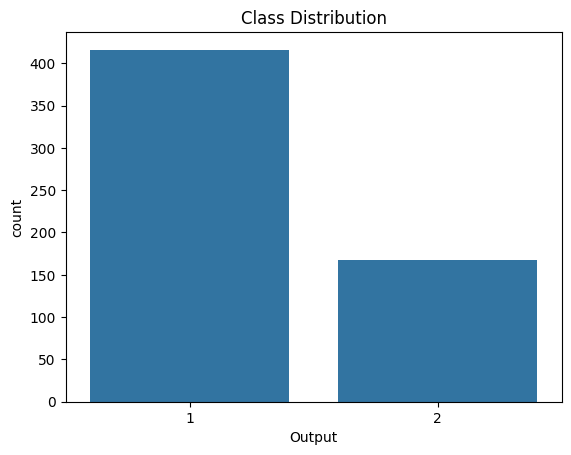

In [10]:
sns.countplot(x="Output", data=data)
plt.title("Class Distribution")
plt.show()

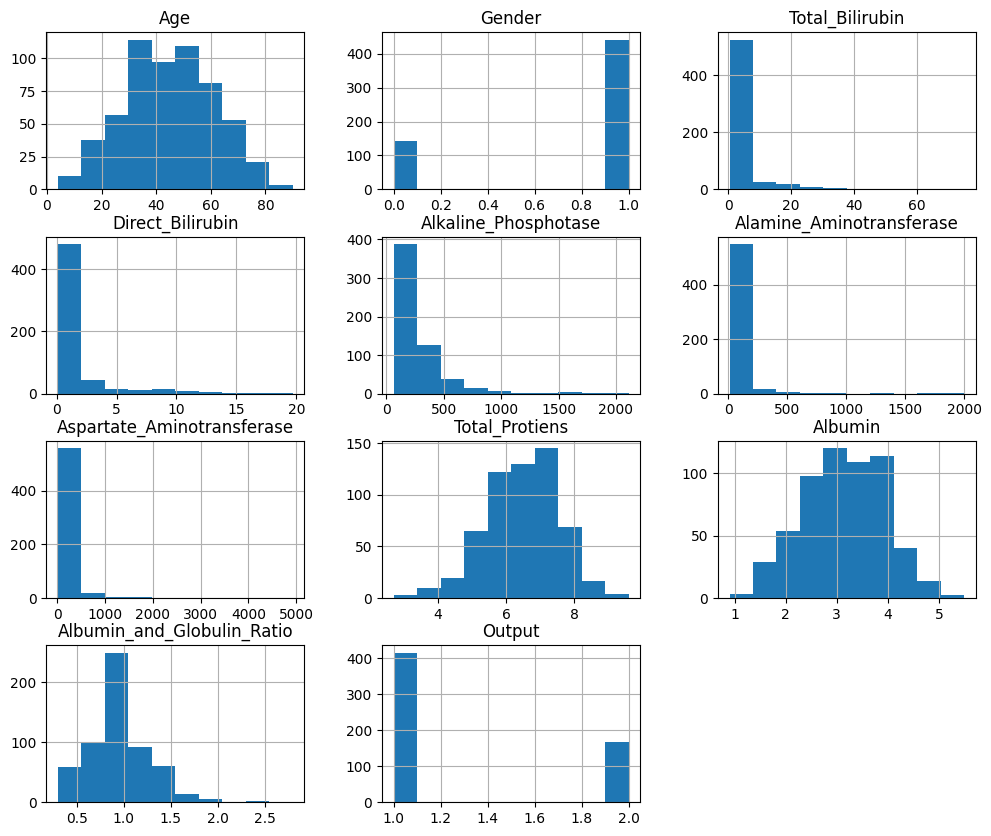

In [11]:
data.hist(figsize=(12,10))
plt.show()

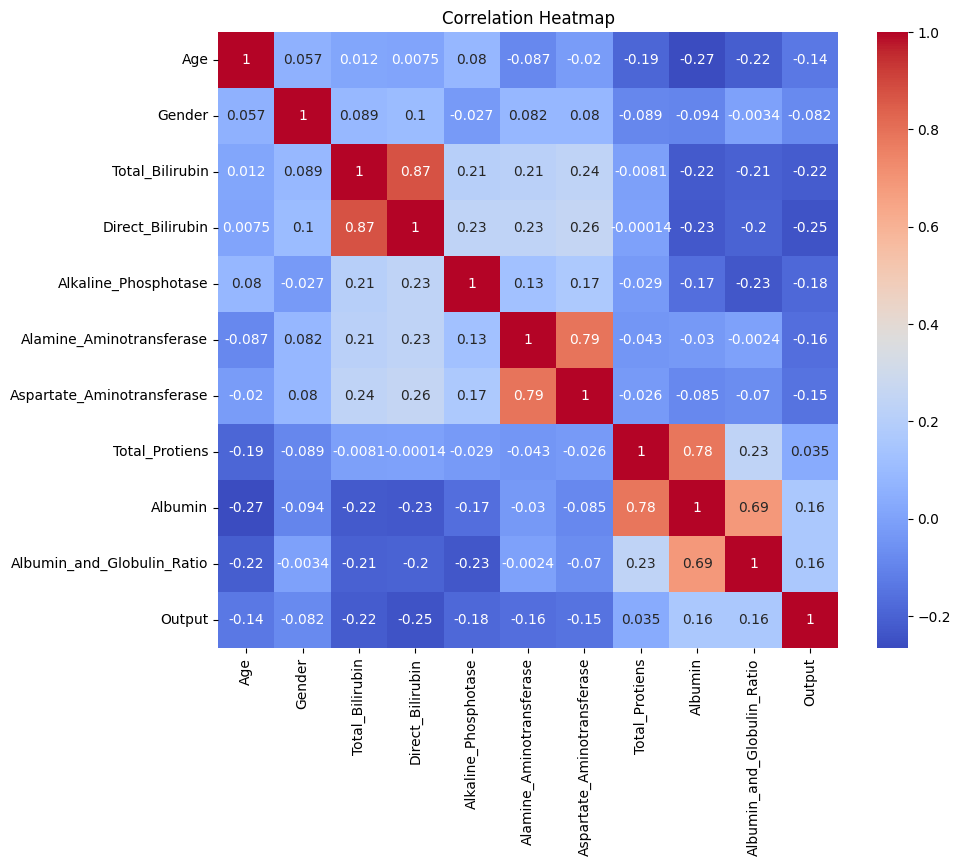

In [12]:
plt.figure(figsize=(10,8))
sns.heatmap(data.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

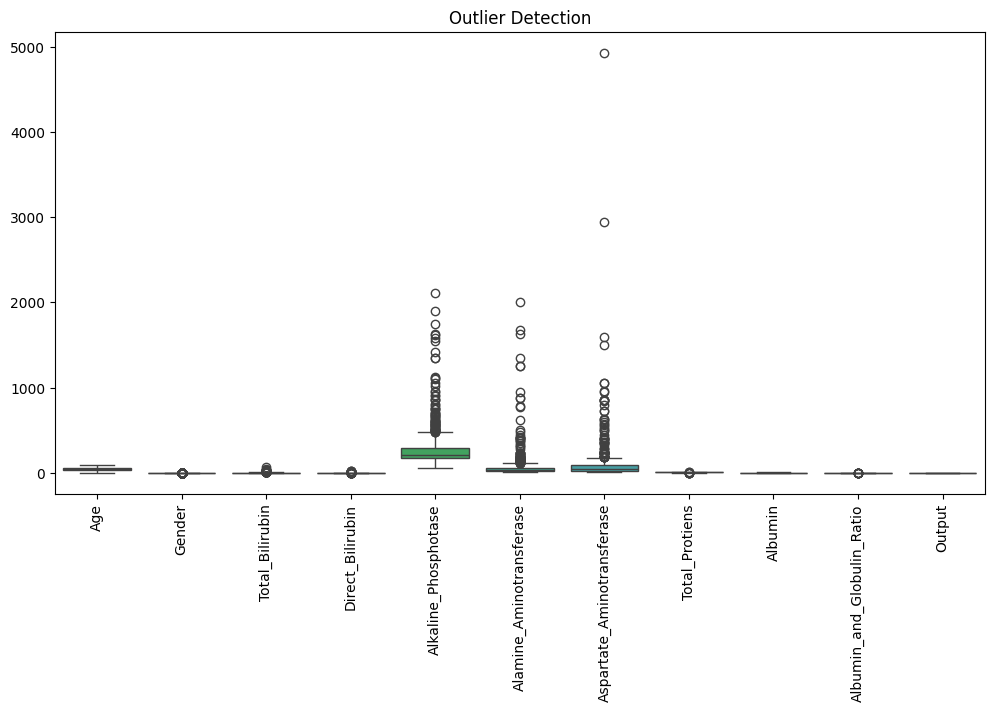

In [13]:
plt.figure(figsize=(12,6))
sns.boxplot(data=data)
plt.xticks(rotation=90)
plt.title("Outlier Detection")
plt.show()

In [14]:
scaler = MinMaxScaler()

scaled = scaler.fit_transform(data)

data = pd.DataFrame(scaled, columns=data.columns)

data.head()

,Age,Gender,Total_Bilirubin,Direct_Bilirubin,Alkaline_Phosphotase,Alamine_Aminotransferase,Aspartate_Aminotransferase,Total_Protiens,Albumin,Albumin_and_Globulin_Ratio,Output
0,0.709302,0.0,0.004021,0.000000,0.060576,0.003015,0.001626,0.594203,0.521739,0.240,0.0
1,0.674419,1.0,0.140751,0.275510,0.310699,0.027136,0.018296,0.695652,0.500000,0.176,0.0
2,0.674419,1.0,0.092493,0.204082,0.208598,0.025126,0.011791,0.623188,0.521739,0.236,0.0
3,0.627907,1.0,0.008043,0.015306,0.058134,0.002010,0.002033,0.594203,0.543478,0.280,0.0
4,0.790698,1.0,0.046917,0.096939,0.064485,0.008543,0.009961,0.666667,0.326087,0.040,0.0


### Observations

- The dataset contains **583 records and 11 features**.
- The target variable indicates **presence of liver disease**.
- Gender was converted from **categorical to numeric**.
- Some features contained **missing values which were filled using mean**.
- Correlation analysis shows relationships between **liver enzyme features**.
- The dataset shows **slight class imbalance** between disease and non-disease cases.

In [16]:
data.to_csv("processed_liver_data.csv", index=False)

print("Processed data saved successfully!")

Processed data saved successfully!
